# Analyse de Données 

## TP 3 : Régression en autonomie

Dans ce TP, nous allons ré-utiliser les techniques vues durant le TP1, le TP2, mais aussi les TD afin d'effectuer une régression sur un nouveau jeu de données.

## Compte-rendu (CC1)

Le compte-rendu de ce TP compte pour la note de CC1, avec celle du quizz.

### Modalités de rendu :

* Envoi au format PDF ou HTML sur Moodle avant **Vendredi 17 Octobre à 9h45**
* Le compte-rendu comportera les réponses aux questions rédigées ainsi que les graphiques illustratifs et le code générant les valeurs, graphiques, ou toute autre information demandée.
* Les compte-rendus se font par deux ou individuellement. Il y aura un bonus d'un point pour les personnes rédigeant seules (Si deux compte-rendus sont suspectement similaires, je m'autoriserai à ne pas mettre de point bonus).
* Certaines questions sont fermées, d'autres sont plus ouvertes. Pour ces dernières, il n'y a pas une seule bonne réponse; dès lors que l'exécution et l'interprétation sont correctes, vous pouvez avoir tous les points.

### 1 - Chargement des bibliothèques et du jeu de données

In [389]:
import numpy as np    # Calcul numérique
import pandas as pd   # Traitement de jeu de données
import matplotlib.pyplot as plt  # Graphiques

> **1)** Nous allons utiliser le jeu de données Abalone disponible dans le fichier `abalone.zip` décompressé dans le dossier courant. Quelles sont les variables et leurs types? Observer les types des colonnes du jeu données (inférées automatiquement) et les relier aux types des variables.

In [392]:
abalone = pd.read_csv('abalone.data',header=None) # Lecture du jeu de données en csv

In [394]:
abalone # affichage de la variable

,0,1,2,3,4,5,6,7,8
0,M,0.455,0.365,0.095,0.5140,0.2245,0.1010,0.1500,15
1,M,0.350,0.265,0.090,0.2255,0.0995,0.0485,0.0700,7
2,F,0.530,0.420,0.135,0.6770,0.2565,0.1415,0.2100,9
3,M,0.440,0.365,0.125,0.5160,0.2155,0.1140,0.1550,10
4,I,0.330,0.255,0.080,0.2050,0.0895,0.0395,0.0550,7
...,...,...,...,...,...,...,...,...,...
4172,F,0.565,0.450,0.165,0.8870,0.3700,0.2390,0.2490,11
4173,M,0.590,0.440,0.135,0.9660,0.4390,0.2145,0.2605,10
4174,M,0.600,0.475,0.205,1.1760,0.5255,0.2875,0.3080,9
4175,F,0.625,0.485,0.150,1.0945,0.5310,0.2610,0.2960,10


In [396]:
abalone.columns = ['Sex','Length','Diameter','Height','Whole weight','Shucked weight','Viscera weight','Shell weight','Rings']

In [398]:
abalone

,Sex,Length,Diameter,Height,Whole weight,Shucked weight,Viscera weight,Shell weight,Rings
0,M,0.455,0.365,0.095,0.5140,0.2245,0.1010,0.1500,15
1,M,0.350,0.265,0.090,0.2255,0.0995,0.0485,0.0700,7
2,F,0.530,0.420,0.135,0.6770,0.2565,0.1415,0.2100,9
3,M,0.440,0.365,0.125,0.5160,0.2155,0.1140,0.1550,10
4,I,0.330,0.255,0.080,0.2050,0.0895,0.0395,0.0550,7
...,...,...,...,...,...,...,...,...,...
4172,F,0.565,0.450,0.165,0.8870,0.3700,0.2390,0.2490,11
4173,M,0.590,0.440,0.135,0.9660,0.4390,0.2145,0.2605,10
4174,M,0.600,0.475,0.205,1.1760,0.5255,0.2875,0.3080,9
4175,F,0.625,0.485,0.150,1.0945,0.5310,0.2610,0.2960,10


In [400]:
abalone.dtypes

Sex                object
Length            float64
Diameter          float64
Height            float64
Whole weight      float64
Shucked weight    float64
Viscera weight    float64
Shell weight      float64
Rings               int64
dtype: object

In [402]:
abalone.describe(include='all')

,Sex,Length,Diameter,Height,Whole weight,Shucked weight,Viscera weight,Shell weight,Rings
count,4177,4177.000000,4177.000000,4177.000000,4177.000000,4177.000000,4177.000000,4177.000000,4177.000000
unique,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,M,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,1528,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,NaN,0.523992,0.407881,0.139516,0.828742,0.359367,0.180594,0.238831,9.933684
std,NaN,0.120093,0.099240,0.041827,0.490389,0.221963,0.109614,0.139203,3.224169
min,NaN,0.075000,0.055000,0.000000,0.002000,0.001000,0.000500,0.001500,1.000000
25%,NaN,0.450000,0.350000,0.115000,0.441500,0.186000,0.093500,0.130000,8.000000
50%,NaN,0.545000,0.425000,0.140000,0.799500,0.336000,0.171000,0.234000,9.000000
75%,NaN,0.615000,0.480000,0.165000,1.153000,0.502000,0.253000,0.329000,11.000000


Pour ce jeu de donnée, il y a 9 variables: 
- **Sex** : Qualitatif nominale avec ses modalités {M,F,I}
- **Lenght, Diameter, Height, Whole weight, Strucked weight, Vicera weight, Shell weight** : Quantitaifs continue
- **Rings** : Quantitatifs discrète 

On remarque que les statistiaues descriptives ont été fait uniquement pour dess variables numériques. Pour des types "objets" comme `Sex`, on peut utiliser la ligne code :

In [406]:
abalone.describe(include = np.object_)

,Sex
count,4177
unique,3
top,M
freq,1528


D'autre part, on observe que toutes les variables contiennent des valeurs manquantes (`NaN`). Il est donc nécessaire de les remplacer par la médiane ou de le normaliser.

In [409]:
np_abalone = abalone.values
np_abalone

array([['M', 0.455, 0.365, ..., 0.101, 0.15, 15],
       ['M', 0.35, 0.265, ..., 0.0485, 0.07, 7],
       ['F', 0.53, 0.42, ..., 0.1415, 0.21, 9],
       ...,
       ['M', 0.6, 0.475, ..., 0.2875, 0.308, 9],
       ['F', 0.625, 0.485, ..., 0.261, 0.296, 10],
       ['M', 0.71, 0.555, ..., 0.3765, 0.495, 12]], dtype=object)

## 2 - Objectif d'inférence

Dans ce TP, notre but va être de prédire l'âge d'une ormeau (abalone en anglais) à partir de ses caractéristiques physiques: 
    
    'Sex','Length','Diameter','Height','Whole weight','Shucked weight','Viscera weight','Shell weight' 
    
L'âge d'un ormeau est déterminé en coupant la coquille à travers le cône, en la colorant et en comptant le nombre d'anneaux (variable `Rings`) à l'aide d'un microscope (une tâche ennuyeuse et qui prend beaucoup de temps) puis en ajoutant 1.5 ans. 

L'objectif ici est de prédire le nombre d'anneaux `Rings` à partir des caractéristiques physiques ci-dessus.

In [412]:
abalone['Age'] = abalone['Rings'] + 1.5

In [414]:
abalone

,Sex,Length,Diameter,Height,Whole weight,Shucked weight,Viscera weight,Shell weight,Rings,Age
0,M,0.455,0.365,0.095,0.5140,0.2245,0.1010,0.1500,15,16.5
1,M,0.350,0.265,0.090,0.2255,0.0995,0.0485,0.0700,7,8.5
2,F,0.530,0.420,0.135,0.6770,0.2565,0.1415,0.2100,9,10.5
3,M,0.440,0.365,0.125,0.5160,0.2155,0.1140,0.1550,10,11.5
4,I,0.330,0.255,0.080,0.2050,0.0895,0.0395,0.0550,7,8.5
...,...,...,...,...,...,...,...,...,...,...
4172,F,0.565,0.450,0.165,0.8870,0.3700,0.2390,0.2490,11,12.5
4173,M,0.590,0.440,0.135,0.9660,0.4390,0.2145,0.2605,10,11.5
4174,M,0.600,0.475,0.205,1.1760,0.5255,0.2875,0.3080,9,10.5
4175,F,0.625,0.485,0.150,1.0945,0.5310,0.2610,0.2960,10,11.5


> **2)** La variable `Age` a été ajoutée au jeu de données. (**Attention :** cette variable ne doit pas être utilisée comme variable explicative) Quelle est la corrélation entre la variable `Rings` et la variable `Age` ? *Répondre par un argument théorique et un calcul informatique*  

On a ici une transformation linéaire : `Age = Rings + 1,5` ; la corrélation de Pearson vaut donc 1. 
Comme des variables `Age` et `Rings` sont des variables quantitatives , on peut érudier la corrélation entre eux. Dans un premier temps, on représente graphiquement ces deux variables.

In [418]:
abalone[["Rings","Age"]]

,Rings,Age
0,15,16.5
1,7,8.5
2,9,10.5
3,10,11.5
4,7,8.5
...,...,...
4172,11,12.5
4173,10,11.5
4174,9,10.5
4175,10,11.5


Text(0, 0.5, 'Rings')

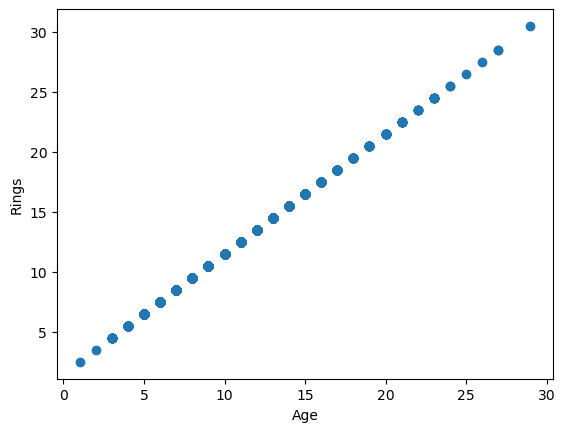

In [420]:
plt.scatter(abalone["Rings"],abalone["Age"])
plt.xlabel("Age")
plt.ylabel("Rings")

**Commentatire** : A l'aide du graphique, on remarque une forte corrélation positive entre le nombre des anneaux `Rings`et l'âge `Age`des ormeaux : plus l'âge augmente plus le nombre des anneaux augmente. Ces deux variables sont parfaitement linéaires.

Ensuite, on calcule le coefficient de corrélation de Pearson en utilisant la fonction **corr()** de pandas.

In [424]:
abalone[["Rings","Age"]].corr()

,Rings,Age
Rings,1.0,1.0
Age,1.0,1.0


**Commentaire :** **Le coefficient de corrélation de Pearson** entre `Rings` et `Age` est positive et égale à 1. Cela signifie qu'elles sont parfaitement corrélées : plus l'âge augmente plus le nombre d'anneaux augmente. Ce résultat confirme la transformation linéaire entre ces deux variables. 

### 3 - Exploration de variables

> **3)** Étudier la corrélation entre les variables continues:
> * Quelles variables sont les plus corrélées entre elles, les moins corrélées entre elles? 
> * Quelles variables semblent les plus utiles pour prédire le nombre d'anneaux? 
> * Comment peut-on transformer les variables pour augmenter leur corrélation avec `Rings`?
>
> *Pour chacun des points, donner une réponse numérique et une représentation graphique*

In [429]:
abalone.corr(numeric_only=True)

,Length,Diameter,Height,Whole weight,Shucked weight,Viscera weight,Shell weight,Rings,Age
Length,1.000000,0.986812,0.827554,0.925261,0.897914,0.903018,0.897706,0.556720,0.556720
Diameter,0.986812,1.000000,0.833684,0.925452,0.893162,0.899724,0.905330,0.574660,0.574660
Height,0.827554,0.833684,1.000000,0.819221,0.774972,0.798319,0.817338,0.557467,0.557467
Whole weight,0.925261,0.925452,0.819221,1.000000,0.969405,0.966375,0.955355,0.540390,0.540390
Shucked weight,0.897914,0.893162,0.774972,0.969405,1.000000,0.931961,0.882617,0.420884,0.420884
Viscera weight,0.903018,0.899724,0.798319,0.966375,0.931961,1.000000,0.907656,0.503819,0.503819
Shell weight,0.897706,0.905330,0.817338,0.955355,0.882617,0.907656,1.000000,0.627574,0.627574
Rings,0.556720,0.574660,0.557467,0.540390,0.420884,0.503819,0.627574,1.000000,1.000000
Age,0.556720,0.574660,0.557467,0.540390,0.420884,0.503819,0.627574,1.000000,1.000000


**Commentaire** 
A partir de ce tableau ci dessus, on observe que les coefficients de corrélation les plus élevées sont ceux entre les variables de taille et de poids :
- "Lenght" et "Diameter" : **r = 0.986812**, corrélation très forte et positive;
- "Whole weight", "Shucked weight", "Shell weigh" sont également très corrélés : **r ≈ 0,9**.
A l'inverse, "Shucked Weight" et "Height" sont les plus faibles corrélées car leur coefficient est **0.774972**, ce qui reste une corrélation positive modérée.

Généralement, ces résultats indiquent que les dimensions physiques de l'ormeau sont fortement liées entre elles.

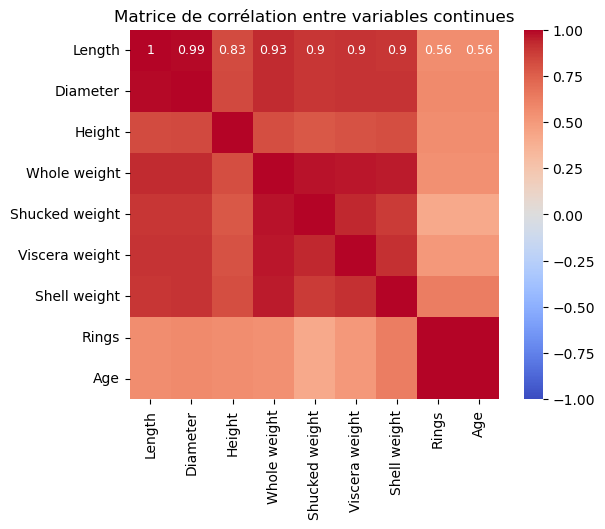

In [432]:
import seaborn as sns
sns.heatmap(abalone.corr(numeric_only=True), annot=True, square=True, cmap='coolwarm', annot_kws={'size': 9}, vmin=-1.0, vmax=1.0)
plt.title("Matrice de corrélation entre variables continues")
plt.show()

Cette matrice permet de visualiser les liens entre les variables du jeu de données.

Afin de bien connaître la force relation des autres variables continues avec le nombre des anneaux d'un ormeau, il est pertinent d'extraire uniquement la colonne correspondant à Rings. 

La fonction **sort_values()** est utilisée pour trier les coefficients de corrélation dans l'ordre croissante. Cela permet de repérer rapidement les variables les plus fortement corrélées avec Rings, c’est-à-dire celles qui seront les plus utiles pour la prédiction.

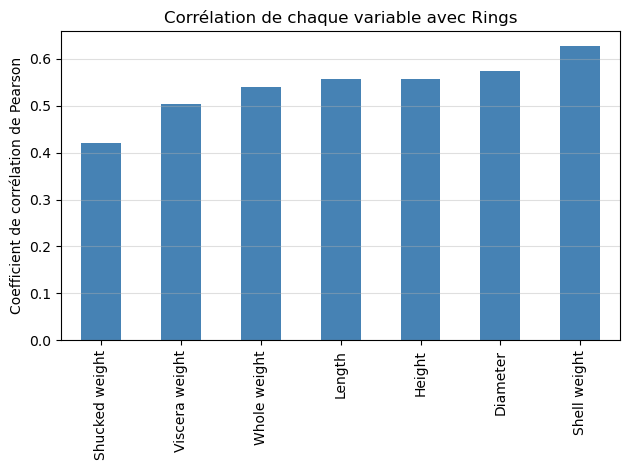

In [436]:
num_cols = ['Length','Diameter','Height','Whole weight','Shucked weight','Viscera weight','Shell weight','Rings']
corr_avec_rings = abalone[num_cols].corr()['Rings'].sort_values(ascending=True)

corr_avec_rings.drop("Rings").plot(kind='bar', color='steelblue')
plt.title("Corrélation de chaque variable avec Rings")
plt.ylabel("Coefficient de corrélation de Pearson")
plt.grid(axis='y', alpha=0.4)
plt.tight_layout()
plt.show()

**Commentaire** :
À partir du tableau et du graphique de corrélation, on observe que les variables les plus corrélées avec Rings sont :
- `Shell weight` (**r = 0,628**) la plus corrélée
- `Diameter` (**r = 0,575**)
Tandis que `Shucked weight`est la moins corrélée (**r = 0,421**)
Ces variables présentent les corrélations les plus fortes et sont donc les plus utiles pour prédire le nombre d’anneaux, l'âge est inclus.

Les variables de taille (Length, Height) et de poids (Whole weight, Viscera weight) ,montrent des corrélations positives mais un peu plus faibles (**r = 0,50 - 0,55**).

Pour augmenter la corrélation avec le variable `Rings`, on peut appliquer le logarithmes sur les variables de poids pour réduire l'effet des grands valeurs. D'autre facon que l'on peut faire est l'utilisation des racines carrées car les valeurs sont proches de 0.

> **4)** Étudier la corrélation entre la variable `Sex` et la variable `Rings`. *Donner une réponse numérique et une représentation graphique*
> Quelles différences observez vous entre les sexes male (M), female (F), et infant (I) ?

In [441]:
abalone[["Sex","Rings"]]

,Sex,Rings
0,M,15
1,M,7
2,F,9
3,M,10
4,I,7
...,...,...
4172,F,11
4173,M,10
4174,M,9
4175,F,10


In [443]:
A = pd.crosstab(abalone['Sex'],abalone['Rings'])
A

Rings,1,2,3,4,5,6,7,8,9,10,...,19,20,21,22,23,24,25,26,27,29
Sex,,,,,,,,,,,,,,,,,,,,,
F,0,0,0,0,4,16,44,122,238,248,...,15,12,7,3,6,1,1,0,1,1
I,1,1,12,51,100,216,267,274,173,92,...,2,2,1,0,0,0,0,0,0,0
M,0,0,3,6,11,27,80,172,278,294,...,15,12,6,3,3,1,0,1,1,0


On calcule le coefficient du chi-deux $\chi^2$ et de Grammer $V^2$ pour observer la corrélation de ce deux variables.

In [446]:
A.sum(axis = 0)

Rings
1       1
2       1
3      15
4      57
5     115
6     259
7     391
8     568
9     689
10    634
11    487
12    267
13    203
14    126
15    103
16     67
17     58
18     42
19     32
20     26
21     14
22      6
23      9
24      2
25      1
26      1
27      2
29      1
dtype: int64

In [448]:
A.sum(axis = 1)

Sex
F    1307
I    1342
M    1528
dtype: int64

In [450]:
C = np.outer(A.sum(axis = 1),A.sum(axis = 0))/A.sum().sum() # effectifs théoriques
C

array([[  0.312904  ,   0.312904  ,   4.69355997,  17.83552789,
         35.98395978,  81.0421355 , 122.34546325, 177.72947091,
        215.59085468, 198.38113479, 152.38424707,  83.54536749,
         63.51951161,  39.42590376,  32.2291118 ,  20.96456787,
         18.14843189,  13.14196792,  10.01292794,   8.13550395,
          4.38065597,   1.87742399,   2.81613598,   0.625808  ,
          0.312904  ,   0.312904  ,   0.625808  ,   0.312904  ],
       [  0.32128322,   0.32128322,   4.81924826,  18.3131434 ,
         36.94757003,  83.21235336, 125.62173809, 182.48886761,
        221.36413694, 203.69355997, 156.46492698,  85.7826191 ,
         65.22049318,  40.48168542,  33.09217141,  21.52597558,
         18.63442662,  13.49389514,  10.28106296,   8.35336366,
          4.49796505,   1.92769931,   2.89154896,   0.64256644,
          0.32128322,   0.32128322,   0.64256644,   0.32128322],
       [  0.36581278,   0.36581278,   5.48719176,  20.8513287 ,
         42.06847019,  94.74551113, 14

In [452]:
# Coefficients du chi2

chi2coeffs = (A-C)**2/C 
chi2coeffs

Rings,1,2,3,4,5,6,7,8,9,10,...,19,20,21,22,23,24,25,26,27,29
Sex,,,,,,,,,,,,,,,,,,,,,
F,0.312904,0.312904,4.693560,17.835528,28.428602,52.200986,50.169507,17.474727,2.329272,12.410614,...,2.483878,1.835698,1.566195,0.671227,3.599610,0.223742,1.508772,0.312904,0.223742,1.508772
I,1.433802,1.433802,10.699427,58.342283,107.601364,211.898335,159.111100,45.889305,10.566706,61.246175,...,6.670128,4.832213,2.720288,1.927699,2.891549,0.642566,0.321283,0.321283,0.642566,0.321283
M,0.365813,0.365813,1.127375,10.577837,22.944734,48.439807,27.777781,6.161888,2.672783,16.614262,...,0.926907,0.651285,0.150736,0.295335,0.025954,0.098445,0.365813,1.099452,0.098445,0.365813


In [454]:
chi2 = chi2coeffs.sum().sum()
chi2

1316.07973176115

In [456]:
#Coefficient de Grammer 

V2 = chi2/A.sum().sum()
V2

0.31507774282048123

**Commentaire :**
Le coefficient de chi deux est loin de 0, cela signifie que les varaibles `Sex`et `Rings`ne sont pas indépendantes. Les corrélations Rings–(Length,Diameter,Height) varient légèrement selon Sex. Les individus **I (infant)** montrent en général des valeurs plus faibles et une dispersion différente, ce qui peut affaiblir certaines corrélations.

<Axes: title={'center': 'Rings'}, xlabel='Sex'>

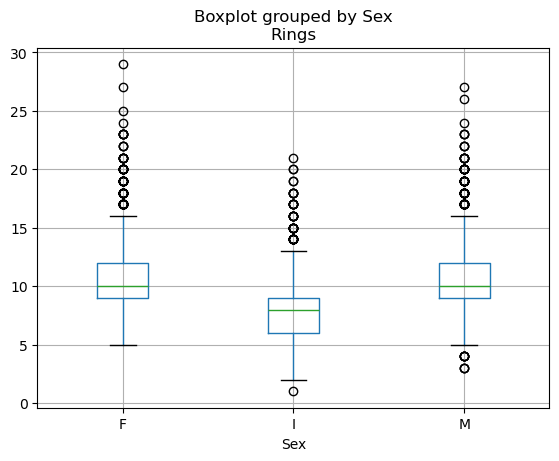

In [459]:
abalone.boxplot(column="Rings",by="Sex")

Sex
F    Axes(0.125,0.11;0.775x0.77)
I    Axes(0.125,0.11;0.775x0.77)
M    Axes(0.125,0.11;0.775x0.77)
Name: Rings, dtype: object

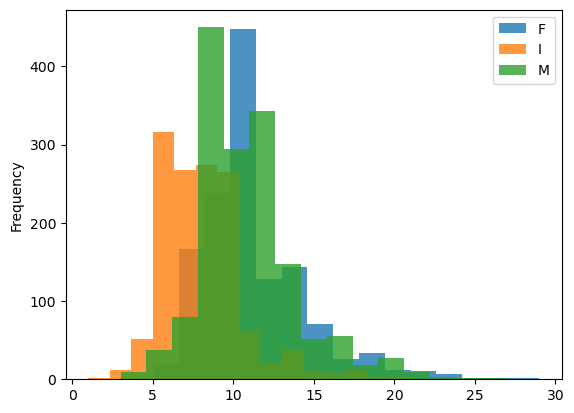

In [461]:
abalone.groupby("Sex")["Rings"].plot.hist(alpha=0.8,bins=15,legend=True)

In [463]:
# On pourra utiliser cette commande et ses dérivés
abalone.groupby("Sex")["Rings"].mean() 

Sex
F    11.129304
I     7.890462
M    10.705497
Name: Rings, dtype: float64

In [465]:
mean_dev = (abalone.groupby("Sex")["Rings"].mean() - abalone["Rings"].mean())**2
mean_dev

Sex
F    1.429505
I    4.174758
M    0.595695
Name: Rings, dtype: float64

In [467]:
freq = abalone.groupby("Sex")["Rings"].count()/abalone["Rings"].count()
freq

Sex
F    0.312904
I    0.321283
M    0.365813
Name: Rings, dtype: float64

In [469]:
#Calculer la variance interclasse 

interclass_variance = np.sum(freq*mean_dev)
interclass_variance

2.0064905899350283

In [643]:
#Calculer la variance totale

total_variance = abalone["Rings"].var(ddof=0)
total_variance

10.392777255475513

In [645]:
#Calculer le rapport de corrélation

eta2 = interclass_variance/total_variance
eta2

0.19306587071111272

**Commentaire** : 
- Les distributions **Masuclin(M)** et **Féminie (F)** sont très similaires et centrées autrour de **10** anneuax (avec la médiane est 10). On observe également pour les deux groupes que quelques valeurs élevées sont à droite.

- En revanche, la médiane du groupe **Infant(I)** est plus basse que celles des autres (environ de **8**) avec une concentration de petites valeurs entre 7 et 9.

Globalement, le nombres d'anneaux des individus I est inférieur à celui des M et F, ce qui est cohérent avec l’âge plus faible des ormeaux infant.

-> Le résultat du rapport de corrélation est proche de 0, cela signifie que les deux variables ne sont pas indépendantes. 

## 4 - Prédiction 

> **5)** Proposer une règle pour prédire le nombre d'anneaux à partir d'une ou de plusieurs variables explicatives. La coder en modifiant la fonction ci-dessous. Observer l'erreur obtenue (voir code ci-dessous) et tenter de passer sous les 12.5 (mon prédicteur naif). 

In [478]:
def prediction(x):
    if x["Sex"] == 'I':
        return 8
    return np.sqrt(x["Shell weight"])/0.04

In [480]:
abalone.apply(prediction, axis=1)

0        9.682458
1        6.614378
2       11.456439
3        9.842510
4        8.000000
          ...    
4172    12.474975
4173    12.759800
4174    13.874437
4175    13.601471
4176    17.589059
Length: 4177, dtype: float64

In [482]:
abalone["Prediction"] = abalone.apply(prediction, axis=1)

In [484]:
from sklearn.metrics import mean_squared_error

La fonction `mean_squared_error` calcule l'erreur quadratique moyenne (c'est à dire la différence entre prédiction et vraie valeur au carré en moyenne sur les données), ce qui correspond à notre risque empirique.

In [487]:
mean_squared_error(abalone["Prediction"],abalone["Rings"])

12.322749153711825

> **6)** Utiliser le régresseur des k plus proches voisins ci-dessous pour prédire le nombre d'anneaux à partir d'une ou de plusieurs variables explicatives. Évaluer sa performance par rapport aux méthodes précédentes. Régler la valeur de $k$ par la methode de votre choix.
> 
> *Le plus vous utilisez de variables explicatives, le plus performant votre modèle pourrait être, et meilleure votre note*

In [539]:
from sklearn.neighbors import KNeighborsClassifier
k = 3
clf = KNeighborsClassifier(n_neighbors=k)

In [541]:
X = abalone[['Length','Diameter','Height','Whole weight','Shucked weight','Viscera weight','Shell weight' ]]
X

,Length,Diameter,Height,Whole weight,Shucked weight,Viscera weight,Shell weight
0,0.455,0.365,0.095,0.5140,0.2245,0.1010,0.1500
1,0.350,0.265,0.090,0.2255,0.0995,0.0485,0.0700
2,0.530,0.420,0.135,0.6770,0.2565,0.1415,0.2100
3,0.440,0.365,0.125,0.5160,0.2155,0.1140,0.1550
4,0.330,0.255,0.080,0.2050,0.0895,0.0395,0.0550
...,...,...,...,...,...,...,...
4172,0.565,0.450,0.165,0.8870,0.3700,0.2390,0.2490
4173,0.590,0.440,0.135,0.9660,0.4390,0.2145,0.2605
4174,0.600,0.475,0.205,1.1760,0.5255,0.2875,0.3080
4175,0.625,0.485,0.150,1.0945,0.5310,0.2610,0.2960


In [543]:
y = abalone['Rings']
y

0       15
1        7
2        9
3       10
4        7
        ..
4172    11
4173    10
4174     9
4175    10
4176    12
Name: Rings, Length: 4177, dtype: int64

### Méthode 1 : Entraînement et évalutation sur tout le jeu de données

In [546]:
clf.fit(X,Y)

KNeighborsClassifier(n_neighbors=3)

In [548]:
Y_pred = clf.predict(X)

In [550]:
#Calcule de l'erreur quadratique moyenne 
MSE = mean_squared_error(Y, Y_pred)
print("MSE :", MSE)

MSE : 6.244433804165669


**Interprétation** : On obtient une MSE faible, mais ce résultat est trop optimiste, car le modèle est évalué sur les mêmes données que celles d’apprentissage.

## Méthode 2 : Entraînenement sur un jeu d'entraînement et évaluation sur un  jeu de test

In [592]:
from sklearn.model_selection import train_test_split

In [594]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.33) 

In [596]:
clf.fit(X_train,Y_train)

KNeighborsClassifier(n_neighbors=3)

In [598]:
Y_pred_test = clf.predict(X_test)

In [602]:
#Calcule de l'erreur quadratique moyenne 
MSE_test = mean_squared_error(Y_test, Y_pred_test)
print("MSE :", MSE_test)

MSE : 8.43002175489485


**Interprétation** Cette méthode donne une évaluation plus réaliste des performances du modèle. Le résultat est inférieure au prédicteur naif (12.5), le modèle est donc meilleur que le naïf.

## Méthode 3 : Validation Croiséé

In [605]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(clf, X, Y, cv=3, scoring='neg_mean_squared_error')
print("MSE CV moyenne :", -scores.mean())

MSE CV moyenne : 8.164539514760447


/opt/anaconda3/lib/python3.11/site-packages/sklearn/model_selection/_split.py:700: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=3.
  warnings.warn(


**Interprétation** La validation croisée permet d’obtenir une estimation stable de la performance du modèle. Cependat, les classes de la variable `Rings` sont très nombreuses et certaines ne contiennent q'une seule observation. Par conséquent, la validation croisée stratifiée (**cv=5**) ne peut pas équilibrer tous les plis. Ce n’est pas une erreur, juste simplement un avertissement indiquant que les classes sont déséquilibrées.

**Commentaire** : 
On a utilisé un régresseur KNN avec **k = 3** et les variables explicatives physiques (Length, Diameter, Height, Whole weight, Shucked weight, Viscera weight, Shell weight) et on observe que :

- Pour la prermière méthode, la **MSE = 6,23** est très faible, mais cette mesure est trop optimiste, car le modèle est évalué sur les mêmes données que celle d'apprentissage.

- Avec une séparation train/test (**33%**), la MSE sur le test est d’environ **8,43** , inférieure à 12,5, ce qui montre que le modèle KNN améliore bien la prédiction du nombre d’anneaux.

- La validation croisée confirme une erreur moyenne proche (avec **MSE = 8,41**), prouvant que le modèle KNN ne généralise pas bien sur de nouveaux sous-échantillons, probablement à cause d’une forte variabilité du jeu de données.

→ Le choix **k = 3** permet d’obtenir un bon compromis entre biais et variance : un k trop petit risque de surapprendre des données, un k trop grand lisse trop les prédictions.

Pour vérifier le meilleur k, on pourrait tester plussieurs valeurs (de 3 à 15 par exemple).

In [622]:
from sklearn.model_selection import KFold, cross_val_score, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
import numpy as np

X = abalone[['Sex','Length','Diameter','Height','Whole weight','Shucked weight','Viscera weight','Shell weight']]
y = abalone['Rings']

pre = ColumnTransformer([
    ('cat', OneHotEncoder(drop='first'), ['Sex']),
    ('num', 'passthrough', ['Length','Diameter','Height','Whole weight','Shucked weight','Viscera weight','Shell weight'])
])

knn = Pipeline([
    ('prep', pre),
    ('scaler', StandardScaler(with_mean=False)),
    ('knn', KNeighborsRegressor())
])

cv = KFold(n_splits=5, shuffle=True, random_state=42)

# Chercher le meilleur k
grid = GridSearchCV(knn, param_grid={'knn__n_neighbors':[3,5,7,9,11,15]},
                    cv=cv, scoring='neg_mean_squared_error', n_jobs=-1)
grid.fit(X,y)

mse_cv = -grid.best_score_
k_star = grid.best_params_['knn__n_neighbors']

print(f"Meilleur k = {k_star} | MSE-CV = {mse_cv:.3f}") 

Meilleur k = 15 | MSE-CV = 4.981


Pour optimiser les performances du  modèle et améliorer la stabilité, on peut :

- Réaliser un prétraitement systématique des données (normalisation, suppression ou traitement des valeurs aberrantes, encodage optimal des variables qualitatives)

- ou normaliser les variables pour réduire l’influence des échelles différentes,

- ou encore augmenter la valeur k.

On pourra utiliser la fonction **transform** ou le faire avec `LabelEncoder` de scikit-learn

In [629]:
from sklearn.preprocessing import LabelEncoder

LabelEncoder().fit_transform(abalone["Sex"])

array([2, 2, 0, ..., 2, 0, 2])

In [631]:
abalone["Sex"] = LabelEncoder().fit_transform(abalone["Sex"])

<Axes: >

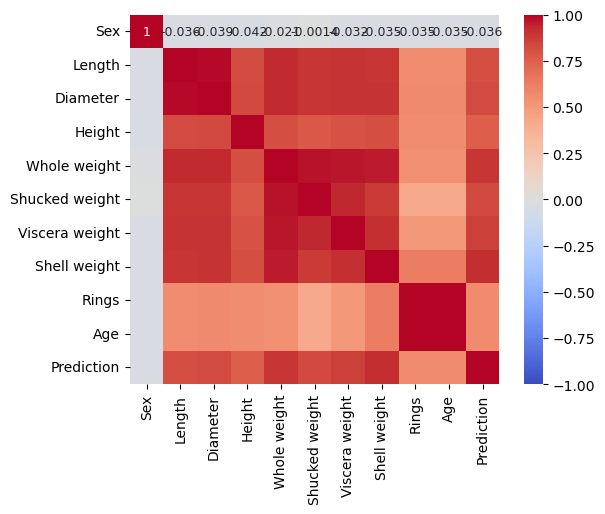

In [635]:
sns.heatmap(abalone.corr(numeric_only=True), annot=True, square=True, cmap='coolwarm', annot_kws={'size': 9}, vmin=-1.0, vmax=1.0)